**PART 1: Data Exploration & Preprocessing**

**Setup & Imports**

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import os

# NLP libraries
import nltk
import spacy
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset download
import kagglehub

# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**Load Dataset**

In [ ]:
# Download dataset
path = kagglehub.dataset_download("shanegerami/ai-vs-human-text")
print("Dataset path:", path)

# List files
files = os.listdir(path)
print("Files:", files)

# Load dataset (limit rows for faster testing)
df = pd.read_csv(os.path.join(path, files[0]), nrows=10000)

# Basic info
print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns)
df.rename(columns={"generated": "label"}, inplace=True)

# Preview
df.head()

Using Colab cache for faster access to the 'ai-vs-human-text' dataset.
Dataset path: /kaggle/input/ai-vs-human-text
Files: ['AI_Human.csv']

Dataset Shape: (10000, 2)

Columns: Index(['text', 'generated'], dtype='object')


,text,label
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


**Exploratory Data Analysis (EDA)**

**Class Distribution**

label
0.0    8964
1.0    1036
Name: count, dtype: int64


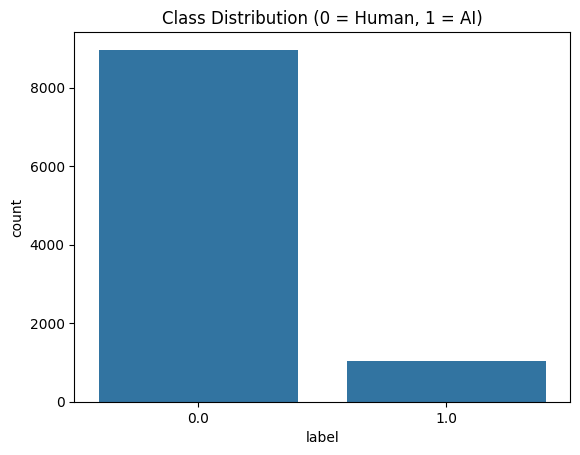

In [ ]:
print(df['label'].value_counts())

sns.countplot(x=df['label'])
plt.title("Class Distribution (0 = Human, 1 = AI)")
plt.show()

**Text Length Analysis**

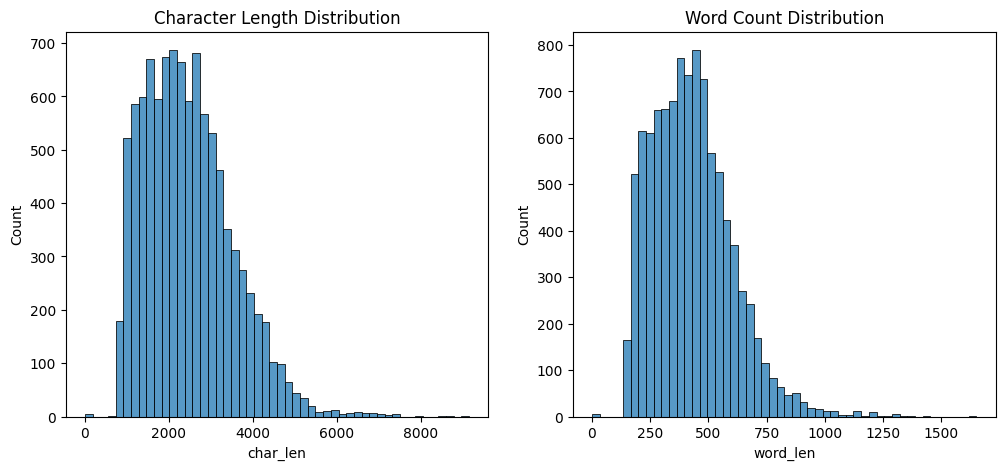

In [ ]:
# Character length
df['char_len'] = df['text'].apply(len)

# Word length
df['word_len'] = df['text'].apply(lambda x: len(x.split()))

# Plot distributions
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['char_len'], bins=50)
plt.title("Character Length Distribution")

plt.subplot(1,2,2)
sns.histplot(df['word_len'], bins=50)
plt.title("Word Count Distribution")

plt.show()

**Compare Human vs AI Length**

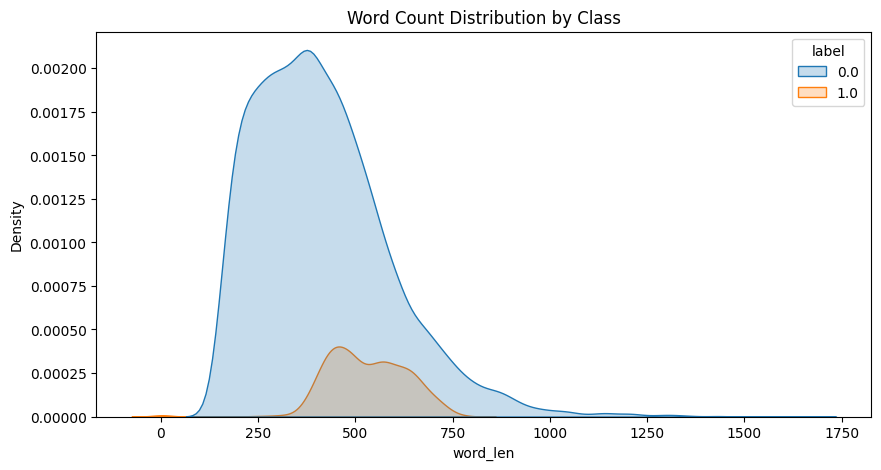

In [ ]:
plt.figure(figsize=(10,5))

sns.kdeplot(data=df, x='word_len', hue='label', fill=True)
plt.title("Word Count Distribution by Class")
plt.show()

**Vocabulary Exploration**

In [ ]:
from collections import Counter
from nltk.tokenize import word_tokenize

all_words = []

for text in df['text']:
    tokens = word_tokenize(text.lower())
    all_words.extend(tokens)

word_freq = Counter(all_words)

print("Top 20 most common words:")
print(word_freq.most_common(20))

Top 20 most common words:
[('the', 235595), ('.', 202990), (',', 165533), ('to', 137489), ('of', 108649), ('and', 106377), ('a', 105488), ('in', 82855), ('is', 71767), ('that', 66772), ('it', 58156), ('are', 40228), ('be', 38836), ('for', 38623), ('this', 37320), ('on', 35746), ('you', 31771), ('have', 30154), ('can', 29433), ('they', 28899)]


**Sample Text Inspection**

In [ ]:
sample_text = df['text'].iloc[1]

print("Sample Text:\n")
print(sample_text[:500])

Sample Text:

Transportation is a large necessity in most countries worldwide. With no doubt, cars, buses, and other means of transportation make going from place to place easier and faster. However there's always a negative pollution. Although mobile transportation are a huge part of daily lives, we are endangering the Earth with harmful greenhouse gases, which could be suppressed.

A small suburb community in Germany called Vauban, has started a "carfree" lifestyle. In this city, markets and stores are plac


**Imports & Setup**

In [ ]:
import numpy as np
import pandas as pd
import string
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

**Preprocessing Function**

In [ ]:
# Initialize tools
stop_words = set(stopwords.words('english'))
punct = set(string.punctuation)
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, method='lemma'):
    # Lowercase
    text = text.lower()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords, punctuation, and non-alpha tokens
    tokens = [
        t for t in tokens
        if t not in stop_words and t not in punct and t.isalpha()
    ]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

**Apply Preprocessing**

In [ ]:
df['processed_text'] = df['text'].apply(preprocess_text)

print("Preprocessing completed!\n")

print("Original:")
print(df['text'].iloc[1][:100])

print("\nProcessed:")
print(df['processed_text'].iloc[1][:100])

Preprocessing completed!

Original:
Transportation is a large necessity in most countries worldwide. With no doubt, cars, buses, and oth

Processed:
transportation large necessity country worldwide doubt car bus mean transportation make going place 


**Train-Test Split**

In [ ]:
# Ensure labels are numeric (0 = human, 1 = AI)
df['label'] = df['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']  # keeps class balance
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 8000, Test size: 2000


**TF-IDF Feature Extraction**

In [ ]:
# Initialize TF-IDF
tfidf = TfidfVectorizer(max_features=10000)

# Fit ONLY on training data
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print(f"\nTrain matrix shape: {X_train_vec.shape}")
print(f"Test matrix shape:  {X_test_vec.shape}")


Train matrix shape: (8000, 10000)
Test matrix shape:  (2000, 10000)


**Inspect TF-IDF Features**

In [ ]:
feature_names = tfidf.get_feature_names_out()

doc_idx = 1
doc_vector = X_train_vec[doc_idx]

nonzero = doc_vector.nonzero()[1]

scores = [(feature_names[i], doc_vector[0, i]) for i in nonzero]
scores = sorted(scores, key=lambda x: x[1], reverse=True)

print("\nTop 10 TF-IDF terms:")
for term, score in scores[:10]:
    print(f"{term:<20} {score:.4f}")


Top 10 TF-IDF terms:
car                  0.2388
sivak                0.1798
live                 0.1784
per                  0.1772
personal             0.1708
future               0.1413
vauban               0.1357
downright            0.1312
two                  0.1288
coming               0.1283


**Train Baseline Models**

**Naive Bayes**

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

nb_preds = nb_model.predict(X_test_vec)

**Logistic Regression**

In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)

lr_preds = lr_model.predict(X_test_vec)

**Evaluation**

In [111]:
print("=== Naive Bayes ===")

nb_acc = accuracy_score(y_test, nb_preds)
print(f"Accuracy: {nb_acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, nb_preds, digits=4))

=== Naive Bayes ===
Accuracy: 0.9905

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9905    0.9947      1793
           1     0.9234    0.9903    0.9557       207

    accuracy                         0.9905      2000
   macro avg     0.9611    0.9904    0.9752      2000
weighted avg     0.9911    0.9905    0.9906      2000



In [112]:
print("=== Logistic Regression ===")

lr_acc = accuracy_score(y_test, lr_preds)
print(f"Accuracy: {lr_acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, lr_preds, digits=4))

=== Logistic Regression ===
Accuracy: 0.9995

Classification Report:
              precision    recall  f1-score   support

           0     0.9994    1.0000    0.9997      1793
           1     1.0000    0.9952    0.9976       207

    accuracy                         0.9995      2000
   macro avg     0.9997    0.9976    0.9986      2000
weighted avg     0.9995    0.9995    0.9995      2000



**PART 3: Hugging Face Transformers (DistilBERT)**

**Install & Import Libraries**

In [ ]:
# Install
!pip install transformers datasets torch accelerate scikit-learn

In [ ]:
import torch
import numpy as np
import pandas as pd
import os

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, f1_score

**Device Setup**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


**Load Dataset into Hugging Face Format**

In [ ]:
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]

df = pd.read_csv(os.path.join(path, csv_file), nrows=10000)
df.rename(columns={"generated": "label"}, inplace=True)
# Ensure labels are integers for single-label classification
df['label'] = df['label'].astype(int)

print("Dataset Shape:", df.shape)
print(df.head())

**Convert to Hugging Face Dataset**

In [73]:
hf_dataset = Dataset.from_pandas(df[['text', 'label']])

print(hf_dataset)
print(hf_dataset.features)

Dataset({
    features: ['text', 'label'],
    num_rows: 10000
})
{'text': Value('string'), 'label': Value('int64')}


**Train-Test Split**

In [74]:
split = hf_dataset.train_test_split(test_size=0.2, seed=42)

train_ds = split['train']
test_ds  = split['test']

print(f"Train size: {len(train_ds)}")
print(f"Test size: {len(test_ds)}")

Train size: 8000
Test size: 2000


**Tokenization**

In [75]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [76]:
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

In [77]:
train_ds = train_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [78]:
train_ds.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label']
)

test_ds.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label']
)

**Load Pre-trained Model**

In [103]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,   # human vs AI
    problem_type="single_label_classification"
)

model.to(device)

print("Model loaded successfully!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!


**Training Configuration**

In [104]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=0.5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    do_eval=True,
    logging_dir="./logs",
    logging_steps=50,
    save_steps=250
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


**Evaluation Metrics**

In [105]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1
    }

**Trainer**

In [106]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

**Fine-Tuning the Model**

In [107]:
!pip uninstall -y torchvision

import sys
print("torchvision" in sys.modules)   #should be False

False


In [108]:
print("Starting training...\n")

trainer.train()

Starting training...



Step,Training Loss
50,0.214335
100,0.024423
150,0.010993
200,0.018514
250,0.017070


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=250, training_loss=0.05706693005561829, metrics={'train_runtime': 57.4344, 'train_samples_per_second': 69.645, 'train_steps_per_second': 4.353, 'total_flos': 132467398656000.0, 'train_loss': 0.05706693005561829, 'epoch': 0.5})

**Evaluation**

In [109]:
print("\nEvaluating model...\n")

results = trainer.evaluate()

print("=== Transformer (DistilBERT) Results ===")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


Evaluating model...



Training Loss,Validation Loss,Step,Accuracy,F1
0.017070,0.010398,250,0.997500,0.988180


=== Transformer (DistilBERT) Results ===
eval_loss: 0.0104
eval_accuracy: 0.9975
eval_f1: 0.9882


**Try!**

In [123]:
def predict_transformer(text):
    # Tokenize
    inputs = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    # Move to same device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Model inference
    with torch.no_grad():
        outputs = model(**inputs)

    # Get predicted class
    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()

    return "AI-generated" if pred == 1 else "Human"

In [128]:
# User input
user_text = input("\nEnter a text to classify:\n")

print("\n=== Prediction ===")

# Transformer (DistilBERT)
bert_result = predict_transformer(user_text)
print(f"DistilBERT:         {bert_result}")


Enter a text to classify:
Emerging areas such as quantum and probabilistic computing further expand the role of materials science in enabling new computing models. At the same time, growing demand for edge computing and real-time AI applications requires energy-efficient hardware capable of local processing.

=== Prediction ===
DistilBERT:         AI-generated
